## Pytorch Basics

## Tensors

Tensors are a specialized data structure that are very similar to arrays and matrices. In PyTorch, we use tensors to encode the inputs and outputs of a model, as well as the model’s parameters.

Tensors are similar to NumPy’s ndarrays, except that tensors can run on GPUs or other hardware accelerators. 

In fact, tensors and NumPy arrays can often share the same underlying memory, eliminating the need to copy data. 

Tensors are also optimized for automatic differentiation (we’ll see more about that later in the Autograd section).

In [2]:
import torch
import numpy as np

### Initializing a Tensor

Tensors can be initialized in various ways. Take a look at the following examples:

1. Directly from data 

Tensors can be created directly from data. The data type is automatically inferred.

In [3]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)
print(x_data)

tensor([[1, 2],
        [3, 4]])


2. From a NumPy array

Tensors can be created from NumPy arrays

In [4]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(x_np)

tensor([[1, 2],
        [3, 4]])


3. From another tensor:

The new tensor retains the properties (shape, datatype) of the argument tensor, unless explicitly overridden.

In [5]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.7854, 0.1639],
        [0.6606, 0.6324]]) 



4. With random or constant values:

shape is a tuple of tensor dimensions. In the functions below, it determines the dimensionality of the output tensor.

In [6]:
shape = (2,3)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.6687, 0.2864, 0.8771],
        [0.6932, 0.5094, 0.5772]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


### Attributes of a Tensor

Tensor attributes describe their shape, datatype, and the device on which they are stored.

In [8]:
tensor = torch.rand(3,4)

print(f"Tensor: \n {tensor} \n")
print(f"Shape of tensor: {tensor.shape}") #shape of the tensor
print(f"Datatype of tensor: {tensor.dtype}") #datatype of the tensor
print(f"Device tensor is stored on: {tensor.device}") #device on which the tensor is stored (CPU or GPU)

Tensor: 
 tensor([[0.2835, 0.6077, 0.9400, 0.9584],
        [0.4426, 0.3594, 0.8760, 0.2858],
        [0.7503, 0.7033, 0.6683, 0.0755]]) 

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### Operations on Tensors

Over 1200 tensor operations, including arithmetic, linear algebra, matrix manipulation (transposing, indexing, slicing), sampling and more.

Each of these operations can be run on the CPU and Accelerator such as CUDA, MPS, MTIA, or XPU. If you’re using Colab, allocate an accelerator by going to Runtime > Change runtime type > GPU.

By default, tensors are created on the CPU. 

We need to explicitly move tensors to the accelerator using .to method (after checking for accelerator availability). 

Keep in mind that copying large tensors across devices can be expensive in terms of time and memory!



In [10]:
#check if GPU is available
torch.cuda.is_available()

False

In [11]:
# We move our tensor to the current accelerator if available
if torch.accelerator.is_available():
    tensor = tensor.to(torch.accelerator.current_accelerator())

#### Standard numpy-like indexing and slicing:

Try out some of the operations from the list. If you’re familiar with the NumPy API, you’ll find the Tensor API a breeze to use.


In [12]:
tensor = torch.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


#### Joining tensors 

You can use `torch.cat` to concatenate a sequence of tensors along a given dimension. See also `torch.stack`, another tensor joining operator that is subtly different from `torch.cat`.



In [17]:
tensor1 = torch.ones(4,4)
tensor2 = torch.rand(4,4)

#join 
tensor3 = torch.concat(tensors=[tensor1, tensor2], dim=1)

print(f"Tensor 1: \n {tensor1} \n")
print(f"Tensor 2: \n {tensor2} \n")
print(f"Tensor 3: \n {tensor3} \n")

Tensor 1: 
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]]) 

Tensor 2: 
 tensor([[0.8809, 0.0489, 0.4914, 0.4729],
        [0.0645, 0.2235, 0.4171, 0.9093],
        [0.2438, 0.6592, 0.3596, 0.5260],
        [0.6612, 0.4374, 0.1367, 0.5645]]) 

Tensor 3: 
 tensor([[1.0000, 1.0000, 1.0000, 1.0000, 0.8809, 0.0489, 0.4914, 0.4729],
        [1.0000, 1.0000, 1.0000, 1.0000, 0.0645, 0.2235, 0.4171, 0.9093],
        [1.0000, 1.0000, 1.0000, 1.0000, 0.2438, 0.6592, 0.3596, 0.5260],
        [1.0000, 1.0000, 1.0000, 1.0000, 0.6612, 0.4374, 0.1367, 0.5645]]) 



#### Arithmetic operations

In [19]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))
print(agg, type(agg))

12.0 <class 'float'>
tensor(12.) <class 'torch.Tensor'>


## Datasets & DataLoaders

Code for processing data samples can get messy and hard to maintain; we ideally want our dataset code to be decoupled from our model training code for better readability and modularity. 

PyTorch provides two data primitives: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset` that allow you to use pre-loaded datasets as well as your own data. `Dataset` stores the samples and their corresponding labels, and `DataLoader` wraps an iterable around the `Dataset` to enable easy access to the samples.

PyTorch domain libraries provide a number of pre-loaded datasets (such as FashionMNIST) that subclass `torch.utils.data.Dataset` and implement functions specific to the particular data. They can be used to prototype and benchmark your model. 

You can find them here: [Image Datasets](https://docs.pytorch.org/vision/stable/datasets.html), [Text Datasets](https://docs.pytorch.org/text/stable/datasets.html), and  [Audio Datasets](https://docs.pytorch.org/audio/stable/datasets.html)


### Loading a Dataset

Here is an example of how to load the [Fashion-MNIST](https://github.com/zalandoresearch/) dataset from TorchVision. Fashion-MNIST is a dataset of Zalando’s article images consisting of 60,000 training examples and 10,000 test examples. Each example comprises a 28×28 grayscale image and an associated label from one of 10 classes.

We load the FashionMNIST Dataset with the following parameters:

* `root` is the path where the train/test data is stored,

* `train` specifies training or test dataset,

* `download=True` downloads the data from the internet if it’s not available at root.

* `transform` and `target_transform` specify the feature and label transformations


Transforms modify or prepare images before training.

Examples:

converting images to tensors
resizing images
normalization
flipping/rotating images

In [ ]:
from torch.utils.data import Dataset  #helps organize data for machine learning, a dataset usually has inputs (images) & labels (categories)
from torchvision import datasets  # Sample built-in computer visoin datasets
from torchvision.transforms import v2 # Has tools for computer vision datasets,image transforms & pretrained models
import matplotlib.pyplot as plt 


training_data = datasets.FashionMNIST(
    root="data",
    train= True,
    download= True,
    transform= v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)


test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform= v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])  #Scales pixel values from: 0 to 255 to 0.0 → 1.0, deep learning models use floats
)

100.0%
100.0%
100.0%
100.0%


Each item in the dataset contains: (image, label)

`img, label = training_data[0]`

`img` → the clothing image tensor

`label` → the category number

### Iterating and Visualizing the Dataset

We can index `Datasets` manually like a list: `training_data[index]`. 

We use matplotlib to visualize some samples in our training data.




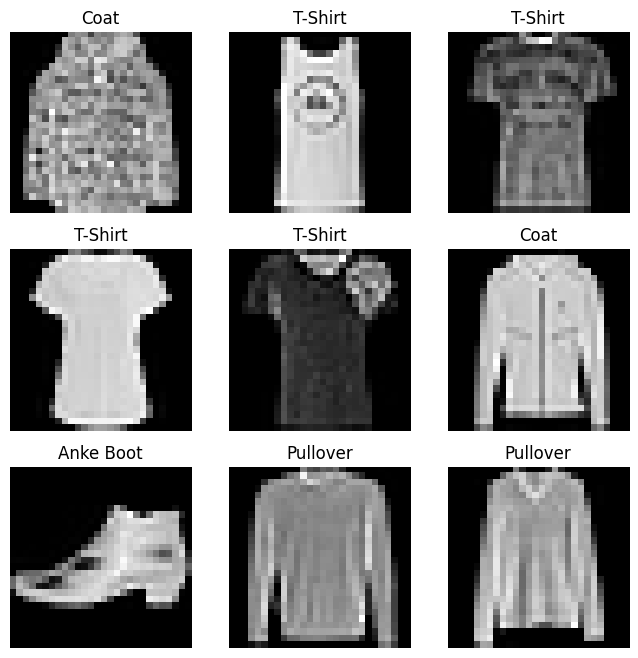

In [22]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: " Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Anke Boot"
}

figure  = plt.figure(figsize=(8,8))

cols, rows = 3, 3

for i in range (1, cols * rows + 1):

    sample_idx = torch.randint(len(training_data), size = (1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label=labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap = "gray")
plt.show()

### Preparing your data for training with DataLoaders

The `Dataset` retrieves our dataset’s features and labels one sample at a time. 

While training a model, we typically want to pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting, and use Python’s `multiprocessing` to speed up data retrieval.

`DataLoader` is an iterable that abstracts this complexity for us in an easy API.

In [24]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

### Iterate through the DataLoader

We have loaded that dataset into the `DataLoader` and can iterate through the dataset as needed. 

Each iteration below returns a batch of `train_features` and `train_labels` (containing `batch_size=64` features and labels respectively). 

Because we specified `shuffle=True`, after we iterate over all batches the data is shuffled (for finer-grained control over the data loading order, take a look at [Samplers](https://docs.pytorch.org/docs/2.12/data.html#data-loading-order-and-sampler)).

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


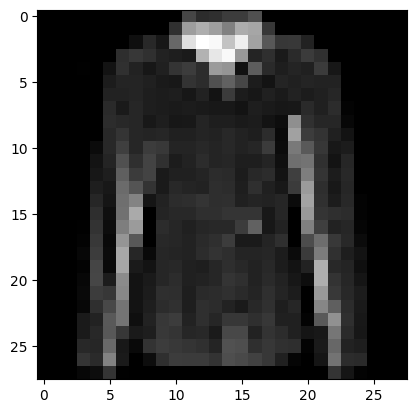

Label: 6


In [25]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")